# Accessing NWM Forecasts using Google BigQuery

This notebook leverages a REST API to access National Water Model data stored in Google Cloud Platform's Big Query service. This API was developed by researchers at BYU, and is currently hosted by CIROH. 

This service provides access to a subset of the data products created by the operational National Water Model. A comprehensive description of these data products can be found at [water.noaa.gov/about/nwm](https://water.noaa.gov/about/nwm).




<div style="background-color: #f7f7f7; padding: 10px; border-radius: 5px;">
    <p><strong>Authors:</strong> 
    <ul>
        <li>Anthony Castronova, <a href="mailto:acastronova@cuahsi.org">acastronova@cuahsi.org</a></li>
        <li>Irene Garousi-Nejad, <a href="mailto:igarousi@cuahsi.org">igarousi@cuahsi.org</a></li>
    </ul>
    </p>
    <p><strong>Last Modified:</strong> 6/9/25</p>
    <p><strong>Description:</strong> This Jupyter notebook is designed as a tutorial to guide learners through the process of accessing operational National Water Model predictions using the CIROH Big Query API.
    </p>
    <p><strong>Software Requirements:</strong> This notebook has been tested using Python v3.11.8 using the following library versions:
    <blockquote>
        <ul>
            <li>matplotlib==3.8.3</li>
            <li>pandas==2.2.1</li>
            <li>geopandas==1.0.1</li>
            <li>shapely==2.0.3</li>
            <li>ipyleaflet==0.18.2</li>
            <li>sidecar==0.7.0</li>
            <li>ipywidgets==8.1.2</li>
        </ul>
    </blockquote>
    </p>
</div>

We'll be accessing operational National Water Model predictions using the CIROH Big Query API. In order to do so, we'll need to use an access key provided by the Alabama Water Institute (AWI). Instructions for doing so can be found at [DocuHub](https://docs.ciroh.org/docs/products/Data%20Management%20and%20Access%20Tools/bigquery-api/). This capability has been established through CIROH research and a complete description of its design and implementation can be found in the paper entitled: ["Design and implementation of a BigQuery dataset and application programmer interface (API) for the U.S. National Water Model"](https://www.sciencedirect.com/science/article/pii/S1364815224001841).

This project ingests operational NWM predictions, which are stored in NetCDF files, into a cloud optimized tabular structure. This makes a once onerous task of accessing these timeseries data a highly efficient and streamlined process. The general architecture for enabling this capability is outlined in the graphic below:

![BigQuery Architecture](img/bigquery-arch.jpg)

Once credentials have been obtained by the AWI, they should be saved in a file named `creds.py`. We're saving our credentials in a separate file so that they are not displayed in the notebook and remain a secret. This file should contain two variables:

```
key="<INSERT API KEY HERE>"
url="https://nwm-api.ciroh.org"
```



In [203]:
import io
import creds
import pandas
import requests
import numpy as np
import matplotlib.pyplot as plt

We'll use the `creds.py` credentials to authenticate our queries with the CIROH BigQuery API. These need to be passed in the header of each each request we make. Define the header information, which we'll reuse throughout the notebook.

In [46]:

API_KEY = creds.key
API_URL = creds.url

header = {
    'x-api-key': API_KEY
}

## Read Analysis and Assimilation Data

> The Standard Analysis and Assimilation configuration cycles hourly and produces a real-time analysis of the current streamflow and other surface and near-surface hydrologic states across the contiguous United States (CONUS). This configuration is internally cycling, with each subsequent Standard Analysis starting from the previous hour’s run. The exception is the 19Z Standard Analysis cycle which ingests initial conditions from the Extended Analysis below. The Standard Analysis also produces restart files each hour which are used to initialize the short-, medium-, and long-range forecast simulations. Meteorological forcing data are drawn from the MRMS Gauge-adjusted and Radar-only observed precipitation products along with short-range RAP and HRRR, while stream-gauge observations are assimilated from the USGS.
>
> <a href=https://water.noaa.gov/about/nwm>https://water.noaa.gov/about/nwm</a>


The CIROH BigQuery API endpoint for the `analysis and assimilation` data accepts the following input parameters:

* **start_time** (str | None): The start time of the data range.
    Defaults to None. If None, defaults to "2018-09-17T00:00:00".
    
* **end_time** (str | None): The end time of the data range.
    Defaults to None. If None, defaults to the current time.

* **comids** (str, optional): A comma-separated list of reach IDs for the forecast.
    Defaults to None.
    Example: "15039097,1239657"

* **hydroshare_id** (str, optional): The hydroshare id with specified comids to
    extract the forecast. If comids is not provided, this will be used
    to extract comids.
    Defaults to None.
    Example: "643dc03878704a30849536e302bdb2c0"

* **output_format** (str): The format of the analysis-assimilation response data.
    Defaults to 'json'.
    Supported values are 'json' and 'csv'.

* **run_offset** (int): The analysis_assim result time offset.
    Defaults to 1.
    Supported values are 1, 2, and 3.

For this notebook, we'll explore the floods that occurred in Vermont in July 2023:

> A major storm caused catastrophic flooding in many parts of Vermont on July 9–12, 2023, resulting in millions of dollars in damages. The high amount of rainfall caused several rivers to peak at record levels, in some cases surpassing records set during Tropical Storm Irene in 2011. The U.S. Geological Survey, in cooperation with the Federal Emergency Management Agency, collected and analyzed data on peak water-surface elevations, peak streamflow, and annual exceedance probabilities at streamgages, lake gages, and selected ungaged locations. Of the 80 streamgages with records ranging from 12 to 94 years, 11 streamgages recorded peak streamflows during the July 2023 flood that were the highest on record, whereas 10 streamgages had peak streamflows with a recurrence interval of 100 years or more. The July 2023 flood affected many of the same communities as Tropical Storm Irene in 2011, but 20 of the 45 monitored streamgages recorded higher peak flows in the July 2023 flood. Seventeen rivers were surveyed for high-water marks during both Tropical Storm Irene and the July 2023 flood, and 32 of the 103 sites had higher water levels during the July 2023 flood compared with Tropical Storm Irene. Flood insurance studies by the Federal Emergency Management Agency were evaluated against the July 2023 flood data. Twenty-one of the 26 locations analyzed had more than a 10 percent difference in the 1-percent annual exceedance probability streamflow.
>
> ...
>
> Prolonged heavy rainfall on July 9–11, 2023, resulted in peak flooding along rivers across Vermont on July 9–12. The flooding caused substantial damage to public and personal property. On July 11, 2023, President Joseph R. Biden, Jr., declared a state of emergency in Vermont, authorizing the Department of Homeland Security and the Federal Emergency Management Agency (FEMA) to provide disaster assistance (White House, 2023). Following the flooding, the Federal disaster declaration for the State resulted in more than $54.7 million in Federal assistance to aid in flood recovery (FEMA, 2024). All 14 Vermont counties were designated to receive public assistance, and residents of nine counties (Caledonia, Chittenden, Lamoille, Orange, Orleans, Rutland, Washington, Windham, and Windsor Counties) were eligible to apply for individual assistance. Major flooding from the Winooski River occurred in the State capital of Montpelier. In response to the Federal disaster declaration, the U.S. Geological Survey (USGS), in cooperation with FEMA, initiated a study to document the July 2023 flood.
> 
> <a href=https://pubs.usgs.gov/publication/sir20255016/full>Flood of July 2023 in Vermont</a>


![Vermont Storm Rainfall](img/vt-storm.png)

For our analysis we'll focus on the West River at South Londonderry, VT during the period of July 9–12, 2023.

![West River](img/west-river-location.png)

Define the input parameters for our location and period of interest.

In [47]:
reach_id = 10102374 
start_time = '2023-07-01'
end_time =  '2023-07-20'
output_format = 'csv'

Build the API request to collect the NWM `analysis and assimilation` predictions.

In [48]:
ENDPOINT = f'{API_URL}/analysis-assim'

params = {
    'comids': reach_id,
    'start_time': start_time,
    'end_time': end_time,
    'output_format': output_format,
}

print(ENDPOINT)
print(params)

https://nwm-api.ciroh.org/analysis-assim
{'comids': 10102374, 'start_time': '2023-07-01', 'end_time': '2023-07-20', 'output_format': 'csv'}


Call the API using the Python `requests` library to collect data.

In [49]:
r = requests.get(ENDPOINT,
                 params=params,
                 headers=header)

A Python `requests` object is returned by the previous cell which contains lots of information about the HTTP request and response. One thing that we should always check is the status code of the response, specifically we want to make sure that the request was successful which would result in an `200` code. For more information about HTTP status codes, see this <a href=https://en.wikipedia.org/wiki/List_of_HTTP_status_codes>Wikipedia article</a>.

In [50]:
if r.status_code == 200:
    print('Request was Sucessful ;)')
else:
    print(f'The request was not successful: {r.status_code}')

Request was Sucessful ;)


Let's preview the response that we recieved from the CIROH BigQuery API. This will be in `csv` format since that's what we specified in the request parameters (i.e. `output_format: csv`). There could be a large amount of data in our response, so let's just view the first 1000 characters so we can see the format of the API response.

In [51]:
# print the first 1000 characters of the response.
print(r.text[0:1000])

feature_id,time,streamflow,velocity
10102374,2023-07-01T00:00:00,2.8299999237060547,0.6699999570846558
10102374,2023-07-01T01:00:00,2.93999981880188,0.6800000071525574
10102374,2023-07-01T02:00:00,2.919999837875366,0.6800000071525574
10102374,2023-07-01T03:00:00,3.0299999713897705,0.6800000071525574
10102374,2023-07-01T04:00:00,3.0799999237060547,0.6899999976158142
10102374,2023-07-01T05:00:00,3.059999942779541,0.6899999976158142
10102374,2023-07-01T06:00:00,3.0899999141693115,0.6899999976158142
10102374,2023-07-01T07:00:00,3.0999999046325684,0.6899999976158142
10102374,2023-07-01T08:00:00,3.259999990463257,0.699999988079071
10102374,2023-07-01T09:00:00,3.2100000381469727,0.699999988079071
10102374,2023-07-01T10:00:00,3.309999942779541,0.7099999785423279
10102374,2023-07-01T11:00:00,3.240000009536743,0.699999988079071
10102374,2023-07-01T12:00:00,3.2100000381469727,0.699999988079071
10102374,2023-07-01T13:00:00,3.0999999046325684,0.6899999976158142
10102374,2023-07-01T14


Convert the raw data into a Pandas Dataframe so we can work with it a bit easier.

In [52]:
df_analysis = pandas.read_csv(io.StringIO(r.text), sep=',')
df_analysis.set_index('time', inplace=True)
df_analysis

,feature_id,streamflow,velocity
time,,,
2023-07-01T00:00:00,10102374,2.83,0.67
2023-07-01T01:00:00,10102374,2.94,0.68
2023-07-01T02:00:00,10102374,2.92,0.68
2023-07-01T03:00:00,10102374,3.03,0.68
2023-07-01T04:00:00,10102374,3.08,0.69
...,...,...,...
2023-07-19T20:00:00,10102374,5.09,0.82
2023-07-19T21:00:00,10102374,4.96,0.81
2023-07-19T22:00:00,10102374,5.00,0.81


We can plot these data very easily using built-in Pandas functions.

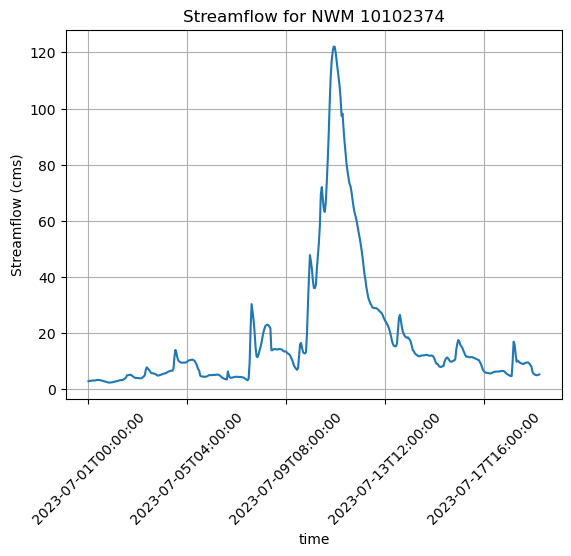

In [53]:
df_analysis.streamflow.plot(grid=True,
                            rot=45,
                            title=f'Streamflow for NWM {reach_id}',
                            ylabel='Streamflow (cms)');

## Read Forecast Data

> **Short Range** - Forced with meteorological data from the HRRR and RAP models, the Short Range Forecast configuration cycles hourly and produces hourly deterministic forecasts of streamflow and hydrologic states out to 18 hours. The model is initialized with a restart file from the Analysis and Assimilation configuration and does not cycle on its own states.
>
> **Medium Range** - The Medium Range Forecast configuration is executed four times per day, forced with GFS model output. Member 1 extends out to 10 days while members 2-6 extend out to 8.5 days. This configuration produces hourly and 3-hourly deterministic output and is initialized with the restart file from the Analysis and Assimilation configuration.
>
> **Long Range** - The Long Range Forecast cycles four times per day (i.e. every 6 hours) and produces a daily 16-member 30-day ensemble forecast. There are 4 ensemble members in each cycle of this forecast configuration, each forced with a different CFS forecast member. It produces 6-hourly streamflow and daily land surface output, and, as with the other forecast configurations, is initialized with a common restart file from the Analysis and Assimilation configuration.
>
> <a href=https://water.noaa.gov/about/nwm>https://water.noaa.gov/about/nwm</a>


The CIROH BigQuery API endpoint for `forecast` data takes the following input parameters:

* **forecast_type** (str): The forecast run to extract data from.
    Supported values are 'long_range', 'medium_range', and 'short_range'.

* **reference_time** (str, optional): The reference time for the forecast.
    If None then defaults to the latest available forecast reference time
    in specified table.
    Defaults to None.
    Example: "2023-11-25 06:00:00 UTC"
  
* **comids** (str, optional): A comma-separated list of reach IDs for the forecast.
    Defaults to None.
    Example: "15039097,1239657"

* **hydroshare_id** (str, optional): The hydroshare id with specified comids to
    extract the forecast. If comids is not provided, this will be used
    to extract comids.
    Defaults to None.
    Example: "643dc03878704a30849536e302bdb2c0"

  
* **ensemble** (str, optional): A comma-separated list of ensembles for the forecast.
    If None then the average of all available ensembles will be taken.
    Defaults to None.
    Supported values are 0 for short_range, 0 to 5 for medium_range, and
    0 to 3 for long_range

* **output_format** (str, optional): The output format for the forecast dataset.
    Defaults to 'json'.
    Supported values are 'json' and 'csv'.


Define input parameters for our request.

In [54]:
forecast_type = 'medium_range'
ensembles = '0,1,2,3,4,5,6'
reference_time = '2023-07-05'

Build the API query object.

In [55]:
ENDPOINT = f'{API_URL}/forecast'

params = {
    'comids': reach_id,
    'forecast_type':  forecast_type,
    'reference_time': reference_time,
    'ensemble': ensembles,
    'output_format': output_format,
}

Call the API using the Python `requests` library to collect data.

In [56]:
r = requests.get(ENDPOINT,
                 params=params,
                 headers=header)

if r.status_code == 200:
    print('Request was Sucessful ;)')
else:
    print(f'The request was not successful: {r.status_code}')

Request was Sucessful ;)


Convert the raw data into a Pandas Dataframe.

In [57]:
df = pandas.read_csv(io.StringIO(r.text), sep=',')
df.set_index('time', inplace=True)
df

,feature_id,reference_time,ensemble,streamflow,velocity
time,,,,,
2023-07-05T01:00:00,10102374,2023-07-05T00:00:00,6,9.480000,1.18
2023-07-05T01:00:00,10102374,2023-07-05T00:00:00,2,9.500000,1.19
2023-07-05T01:00:00,10102374,2023-07-05T00:00:00,4,9.460000,1.18
2023-07-05T01:00:00,10102374,2023-07-05T00:00:00,3,9.460000,1.18
2023-07-05T01:00:00,10102374,2023-07-05T00:00:00,1,9.460000,1.18
...,...,...,...,...,...
2023-07-14T20:00:00,10102374,2023-07-05T00:00:00,0,14.170000,1.14
2023-07-14T21:00:00,10102374,2023-07-05T00:00:00,0,16.830000,1.42
2023-07-14T22:00:00,10102374,2023-07-05T00:00:00,0,16.809999,1.42


We forecasts generated from multiple ensemble members. Let's plot these on the same axis so we can see how they differ.

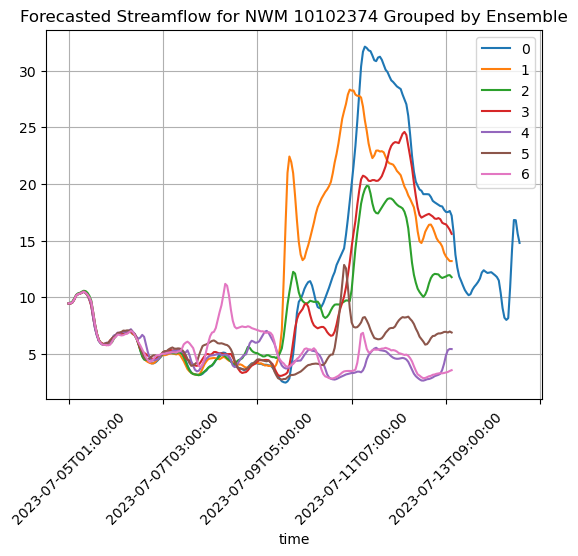

In [58]:
df.groupby('ensemble')['streamflow'].plot(grid=True,
                                          rot=45,
                                          legend=True,
                                          title=f'Forecasted Streamflow for NWM {reach_id} Grouped by Ensemble');

Another way to visualize these data is by plotting their interquartile range. This will help us visualize theses collection of forecasts behave over time, as a shaded area with an upper bound of the 75th percentile and lower bound of the 25th percentile. This is effective in reducing visual clutter while also showing the agreement/disagreement between each forecast. A wide band of shaded area represents disagreement (or higher uncertainty) between series, where as a narrow shaded area represents agreement (or low uncertainty).

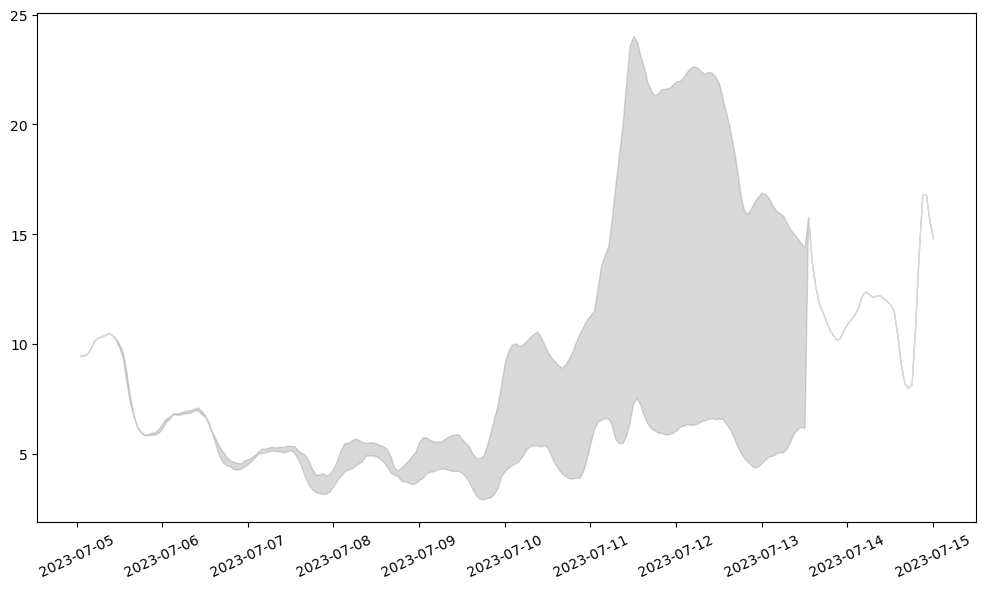

In [59]:
iqr = df.groupby(df.index)['streamflow'].quantile([0.25, 0.75])
iqr = iqr.reset_index()
iqr = iqr.rename(columns={'level_1': 'quantile'})

df_pivot = iqr.pivot(index='time', columns='quantile', values='streamflow')
df_pivot.index = pandas.to_datetime(df_pivot.index)

# Plot the time series for each group
plt.figure(figsize=(10, 6))
plt.fill_between(df_pivot.index, df_pivot[0.25], df_pivot[0.75], color='gray', alpha=0.3);
plt.xticks(rotation=25)
plt.tight_layout()

# Collect Forecast Data for Multiple Reference Times

We can also collect data for multiple forecasts through time. To assist with this, we'll use a utility library called `utils.forecast`. This library wraps the forecast request above in the `concurrent.futures` class which enables us to make parallel requests. This will speed up the collection of data.

In [202]:
from utils import forecast
from datetime import datetime, timedelta

Instantiate the utilities library by passing it our BigQuery key.

In [172]:
forecasts = forecast.Forecasts(creds.key)

Define several reach ids to collect data for. In this scenario, we're only interested in the first ensemble member.

In [173]:
#comids = [6084609, 6084445, 6084621]
comids = [10102374, 10102316, 10102406]
forecast_type = 'medium_range'
ensembles = [0]

Create a list of times for which data will be collected. In the cell below, we define a start time and dynamically generate a list of dates that will be sent to the CIROH BigQuery API.

In [174]:
# start time 
start_date = datetime(2023, 6, 28)

# Number of days to increment (for example, 10 days)
num_days = 20

# Create a list of dates incrementing by day
reference_times = [(start_date + timedelta(days=i)).strftime('%Y-%m-%d') for i in range(num_days)]

print("Generated Reference Times:")
for reference_time in reference_times:
    print(reference_time)

Generated Reference Times:
2023-06-28
2023-06-29
2023-06-30
2023-07-01
2023-07-02
2023-07-03
2023-07-04
2023-07-05
2023-07-06
2023-07-07
2023-07-08
2023-07-09
2023-07-10
2023-07-11
2023-07-12
2023-07-13
2023-07-14
2023-07-15
2023-07-16
2023-07-17


Collect medium_range forecasts for each of the `comids` specied above, for each of the times generated in the previous cell.

In [175]:
forecasts.collect_forecasts(comids,
                            forecast_type,
                            ensembles,
                            reference_times)

Fetching Forecast Data:   0%|          | 0/20 [00:00<?, ?url/s]

Let's double check that we received forecast data for multiple reaches and multiple days.

In [176]:
for fid in forecasts.df.feature_id.unique():
    num_timesteps = len(forecasts.df.loc[forecasts.df.feature_id==fid].time.unique())
    num_ref_times = len(forecasts.df.loc[forecasts.df.feature_id==fid].reference_time.unique())
    print(f'Reach ID: {fid}')
    print(f'\tNumber of Ref Times: {num_ref_times}')
    print(f'\tNumber of Timesteps: {num_timesteps}\n')

Reach ID: 10102316
	Number of Ref Times: 20
	Number of Timesteps: 696

Reach ID: 10102374
	Number of Ref Times: 20
	Number of Timesteps: 696

Reach ID: 10102406
	Number of Ref Times: 20
	Number of Timesteps: 696



Preview the data for one of these reaches.

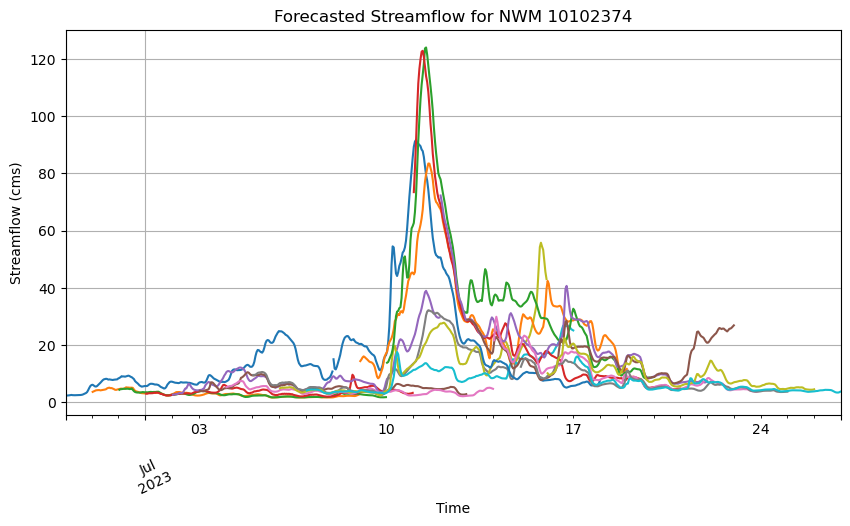

In [177]:
plt, ax = forecasts.plot(comids[0], plot_type='series', ylabel='Streamflow (cms)')
ax.set_title(f'Forecasted Streamflow for NWM {reach_id}')
plt.show()

When we're looking at many timeseries, it can sometimes be helpful to visualize the interquartile range. This descibes the middle 50% of the values at each timestep and shows were the forecasts align.

In [178]:
df_analysis.index = pandas.to_datetime(df_analysis.index)

In [179]:
dat = forecasts.df[forecasts.df.feature_id == comids[0]]

iqr = dat.groupby(dat.time)['streamflow'].quantile([0.25, 0.75])
iqr = iqr.reset_index()
iqr = iqr.rename(columns={'level_1': 'quantile'})
        
df_pivot = iqr.pivot(index='time', columns='quantile', values='streamflow')
df_pivot.index = pandas.to_datetime(df_pivot.index)


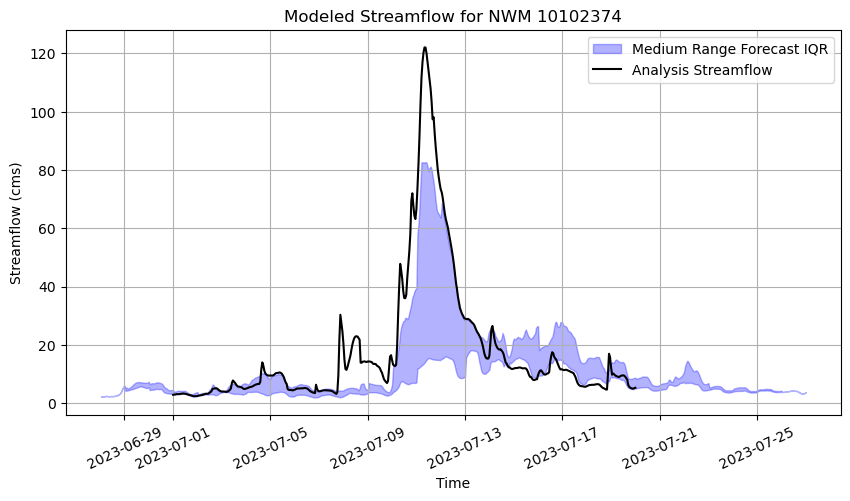

In [181]:
plt, ax = forecasts.plot(comids[0], plot_type='iqr', ylabel='Streamflow (cms)');
ax.set_title(f'Modeled Streamflow for NWM {reach_id}')

fill = ax.collections[-1]  
fill.set_label("Medium Range Forecast IQR")

ax.plot(df_analysis.index, df_analysis['streamflow'], label='Analysis Streamflow', color='black')

ax.legend();

The plot above is a computed IQR in which all forecast data available at any given time are weighted equally. However, we expect the accuracy of a forecast to deteriorate the further it gets from the initial forecast time. One way in which we can simulate this by computing weighted IQR:

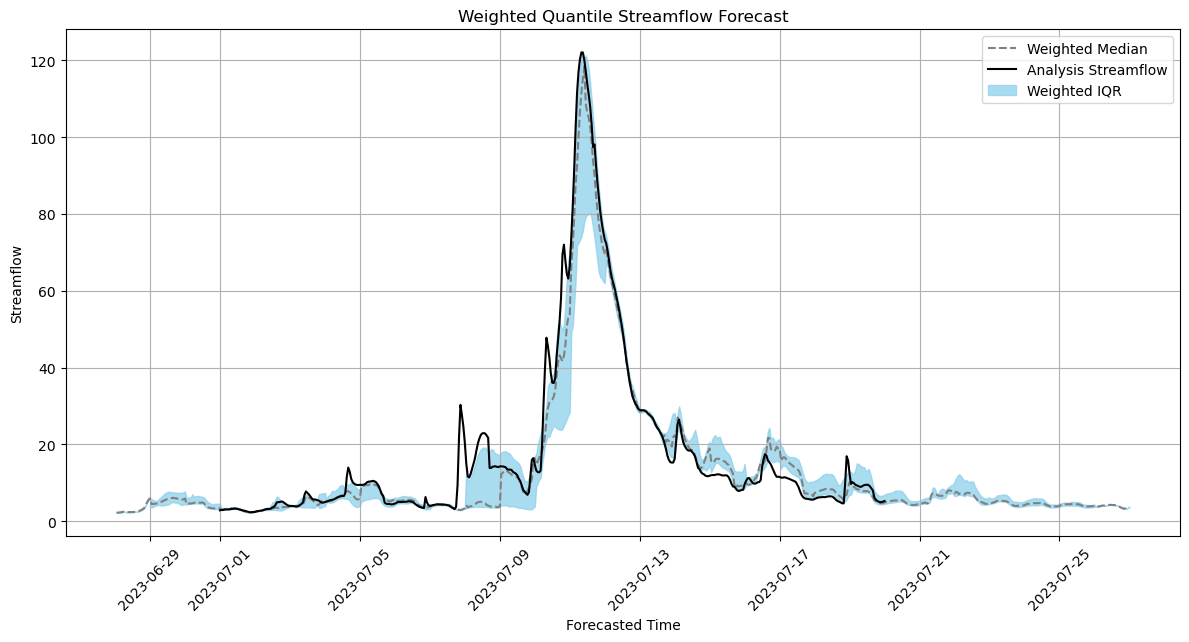

In [201]:

df = dat.copy()

# Ensure datetime types
df['reference_time'] = pandas.to_datetime(df['reference_time'])
df['time'] = pandas.to_datetime(df['time'])

# Compute lead time in hours
df['lead_time_hr'] = (df['time'] - df['reference_time']).dt.total_seconds() / 3600.0

# Set decay constant for weighting (in hours)
tau = 24 * 2
df['weight'] = np.exp(-df['lead_time_hr'] / tau)

# Function to compute weighted quantiles
def weighted_quantile(values, quantiles, sample_weight=None):
    values = np.array(values)
    quantiles = np.array(quantiles)
    if sample_weight is None:
        sample_weight = np.ones(len(values))
    sorter = np.argsort(values)
    values = values[sorter]
    weights = sample_weight[sorter]
    cum_weights = np.cumsum(weights) - 0.5 * weights
    cum_weights /= np.sum(weights)
    return np.interp(quantiles, cum_weights, values)

# group by forecasted time and compute weighted quantiles
iqr_data = []

for t, group in df.groupby('time'):
    q25, q50, q75 = weighted_quantile(
        group['streamflow'].values,
        [0.25, 0.5, 0.75],
        sample_weight=group['weight'].values
    )
    iqr_data.append({'time': t, 'p25': q25, 'p50': q50, 'p75': q75})

iqr_df = pandas.DataFrame(iqr_data).sort_values('time')

# Plot the result
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(iqr_df['time'], iqr_df['p50'], color='grey', linestyle='--', label='Weighted Median')
ax.plot(df_analysis.index, df_analysis['streamflow'], label='Analysis Streamflow', color='black')
ax.fill_between(iqr_df['time'], iqr_df['p25'], iqr_df['p75'], color='skyblue', alpha=0.7, label='Weighted IQR')

ax.set_title('Weighted Quantile Streamflow Forecast')
ax.set_xlabel('Forecasted Time')
ax.set_ylabel('Streamflow')
ax.legend()
plt.tight_layout()
plt.xticks(rotation=45)
plt.grid()
plt.show()


# Creating and Interactive Map

We've included a utility library to demonstrate how these CIROH BigQuery API capabilities can be used in an interactive mapping interface. Reading through the code for producing this map interface is left as an exercise for the reader to complete. The relevant code can be found in the `ForecastMap` class within `./utilities/forecast.py`

In [44]:
f = forecast.ForecastMap(creds.key)
f.asSideCarMap()